# Data experimentation

Downloaded ML-SUPERB data from [HuggingFace (8th edition)](https://huggingface.co/datasets/ftshijt/mlsuperb_8th)/

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

## Folder composition

In [2]:
data_dir = Path("/Users/rodrigopaganini/data/master/speech_nlp_project/eighth_version")
data_dir.exists()

# Internal structure of the data directory:
for item in data_dir.iterdir():
    print(item.name)

M-AILABS
voxpopuli
commonvoice
.DS_Store
fleurs
nchlt
LAD
googlei18n_tts
NST
googlei18n_asr
mls
voxforge
swc
ALFFA
mexico-el


In [3]:
sub_dataset = 'voxpopuli'

for subf in (data_dir / sub_dataset).iterdir():
    print(subf.name)

eng
ron
pol
fra
fin
lit
deu
slk
slv
ita
hun
ces
spa
hrv
nld
est


ML-SUPERB
- Datasets
    - Language acronym
        - `.txt` transcripts (10 min train/dev/test)
        - `wav/` with audio files

In [4]:
# Calculate amount of audio files per language
sub_datasets = [d for d in data_dir.iterdir() if d.is_dir()]
language_counts = {}
for sub in sub_datasets:
    languages = [d.name for d in (data_dir / sub).iterdir() if d.is_dir()]
    for lang in languages:
        if lang not in language_counts.keys():
            language_counts[lang] = 0
        language_counts[lang] += len(list((data_dir / sub / lang / 'wav').iterdir()))

language_counts_df = pd.DataFrame.from_dict(language_counts, orient='index', columns=['count'])
language_counts_df.sort_values('count', inplace=True, ascending=True)

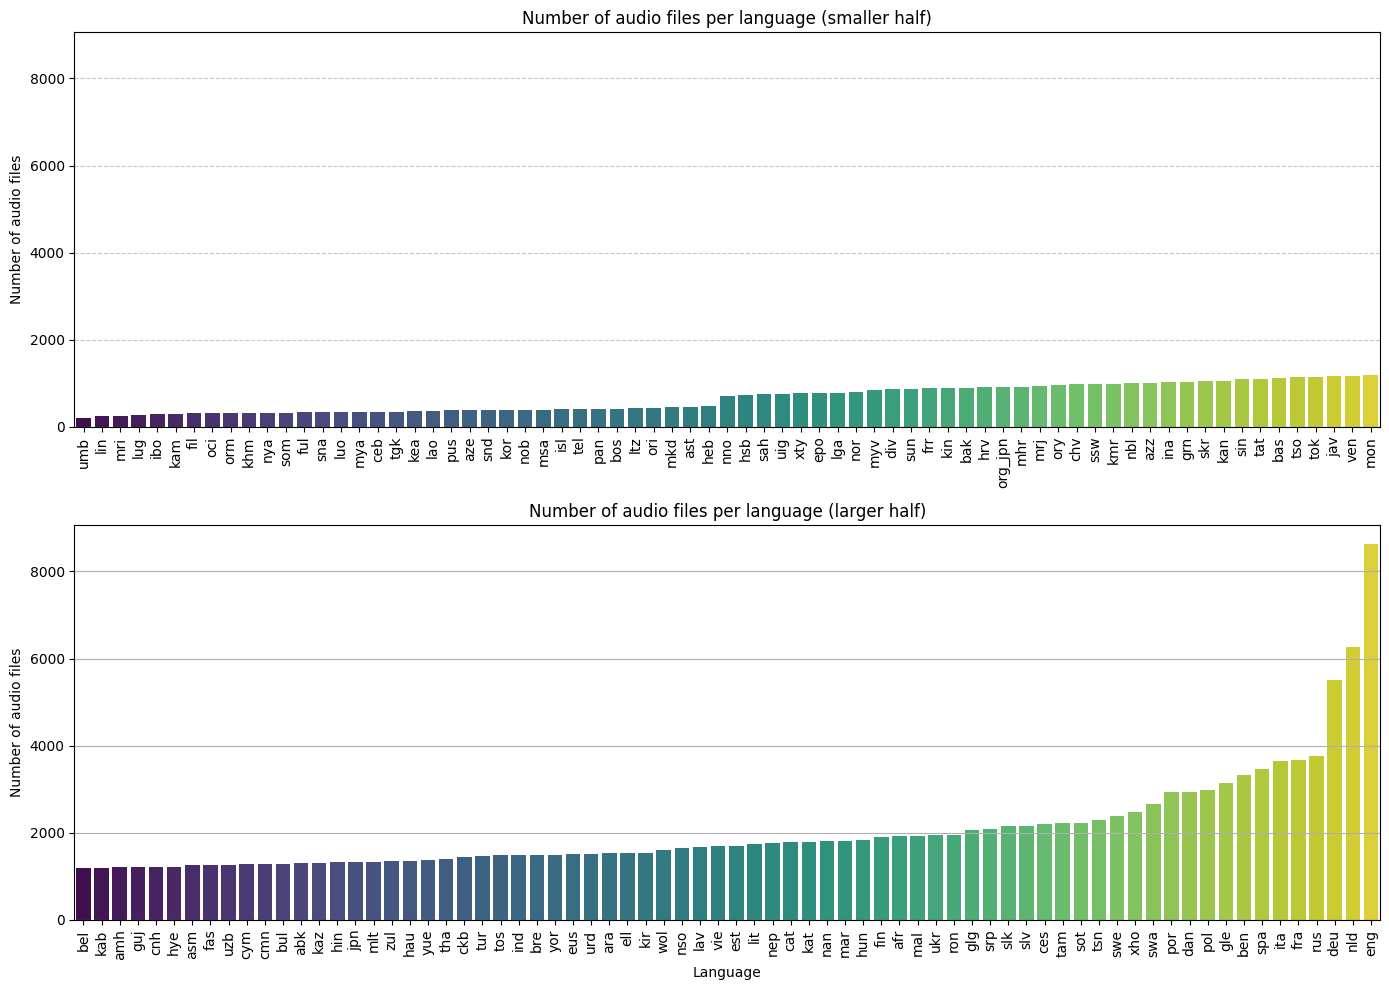

In [5]:
# Split the dataframe into two roughly equal parts and plot each in its own subplot
n = len(language_counts_df)
mid = n // 2

left_df = language_counts_df.iloc[:mid]
right_df = language_counts_df.iloc[mid:]

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharey=True)

sns.barplot(ax=axes[0], x=left_df.index, y=left_df['count'], hue=left_df.index, palette="viridis")
axes[0].set_title("Number of audio files per language (smaller half)")
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of audio files")
axes[0].tick_params(axis='x', rotation=90)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

sns.barplot(ax=axes[1], x=right_df.index, y=right_df['count'], hue=right_df.index, palette="viridis")
axes[1].set_title("Number of audio files per language (larger half)")
axes[1].set_xlabel("Language")
axes[1].set_ylabel("Number of audio files")
axes[1].tick_params(axis='x', rotation=90)
axes[1].grid(axis='y')

plt.tight_layout()
plt.show()

In [6]:
language_counts_df.index.tolist()

['umb',
 'lin',
 'mri',
 'lug',
 'ibo',
 'kam',
 'fil',
 'oci',
 'orm',
 'khm',
 'nya',
 'som',
 'ful',
 'sna',
 'luo',
 'mya',
 'ceb',
 'tgk',
 'kea',
 'lao',
 'pus',
 'aze',
 'snd',
 'kor',
 'nob',
 'msa',
 'isl',
 'tel',
 'pan',
 'bos',
 'ltz',
 'ori',
 'mkd',
 'ast',
 'heb',
 'nno',
 'hsb',
 'sah',
 'uig',
 'xty',
 'epo',
 'lga',
 'nor',
 'myv',
 'div',
 'sun',
 'frr',
 'kin',
 'bak',
 'hrv',
 'org_jpn',
 'mhr',
 'mrj',
 'ory',
 'chv',
 'ssw',
 'kmr',
 'nbl',
 'azz',
 'ina',
 'grn',
 'skr',
 'kan',
 'sin',
 'tat',
 'bas',
 'tso',
 'tok',
 'jav',
 'ven',
 'mon',
 'bel',
 'kab',
 'amh',
 'guj',
 'cnh',
 'hye',
 'asm',
 'fas',
 'uzb',
 'cym',
 'cmn',
 'bul',
 'abk',
 'kaz',
 'hin',
 'jpn',
 'mlt',
 'zul',
 'hau',
 'yue',
 'tha',
 'ckb',
 'tur',
 'tos',
 'ind',
 'bre',
 'yor',
 'eus',
 'urd',
 'ara',
 'ell',
 'kir',
 'wol',
 'nso',
 'lav',
 'vie',
 'est',
 'lit',
 'nep',
 'cat',
 'kat',
 'nan',
 'mar',
 'hun',
 'fin',
 'afr',
 'mal',
 'ukr',
 'ron',
 'glg',
 'srp',
 'slk',
 'slv',
 'ce

In [7]:
language_counts_df.loc[
    [
        # 'rus', 'swa', 'swe', 
        'jpn', 'cmn', 'xty'
    ]
]

,count
jpn,1321
cmn,1287
xty,772


In [8]:
from itertools import chain

def retrieve_language_directories(data_dir, language):
    return chain.from_iterable(f for f in data_dir.glob(f'*/{language}/'))

# ... how will the benchmark consume this?

# Create a subset

In [87]:
print(language_counts_df)

     count
umb    196
lin    246
mri    248
lug    267
ibo    283
..     ...
fra   3676
rus   3773
deu   5510
nld   6255
eng   8627

[143 rows x 1 columns]


count    9966
dtype: int64


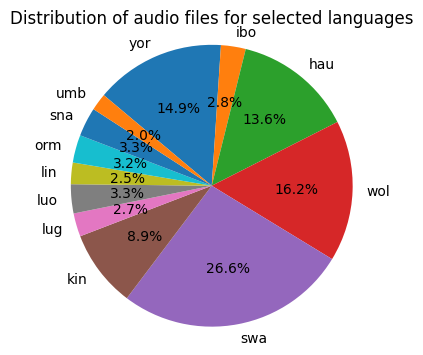

,count
swa,2649
wol,1613
yor,1488
hau,1360
kin,884
luo,332
sna,331
orm,317
ibo,283
lug,267


In [86]:
# First failed attempt
# languages = [
#     # 'swa',
#     # 'swe',
#     'jpn',
#     'cmn',
#     'xty'
# ]

# v02
languages = [
    'yor',
    'ibo',
    'hau',
    'wol',
    'swa',
    'kin',
    'lug',
    'luo',
    'lin',
    'orm',
    'sna',
    'umb'
]

# # v03
# languages = [
#     'swa',
#     'kin',
#     'lug',
#     'lin',
# ]

print(language_counts_df.loc[languages].sum())

plt.figure(figsize=(4, 4))
counts = language_counts_df.loc[languages, 'count']
plt.pie(counts, labels=languages, autopct='%1.1f%%', startangle=140, counterclock=False)
plt.title('Distribution of audio files for selected languages')
plt.axis('equal')
plt.show()

language_counts_df.loc[languages].sort_values('count', ascending=False)

In [82]:
examples_df = (
    pd.DataFrame(rows)
    .sort_values(["language_name", "language_code"])
    .reset_index(drop=True)
)

# Sort examples by their count value in language_counts_df, highest count first
examples_df_sorted = examples_df.set_index('language_code').loc[
    language_counts_df.loc[languages].sort_values('count', ascending=False).index
].reset_index()
examples_df_sorted

,index,language_name,dataset,transcript_file,utt_id,example_text
0,swa,Swahili,ALFFA,transcript_10min_train.txt,ALFFA_swa_000000\tSWH-15-20110303_16k-emission...,mashtaka mkuu wa icc luis
1,wol,Wolof,ALFFA,transcript_10min_train.txt,ALFFA_wol_000000\tWOL_08_lect_0337\tbooy,dem màrse ma yóbbante la kànja
2,yor,Yoruba,fleurs,transcript_10min_train.txt,fleurs_yor_000036\tyo_ng/audio/train/141272731...,A WA FUN NI NI AKOSILE GBOGBO AWON AGBALEJO TO...
3,hau,Hausa,commonvoice,transcript_10min_train.txt,cv_hau_000000,common_voice_ha_26965630.mp3 Ina mamakin idan ...
4,kin,Kinyarwanda,commonvoice,transcript_10min_train.txt,cv_kin_000000,common_voice_rw_20330258.mp3 Yaherukaga gukora...
5,luo,Luo (Kenya and Tanzania),fleurs,transcript_10min_train.txt,fleurs_luo_000046\tluo_ke/audio/train/10746582...,COSTELLO JA RANG OMUOM MAR AUSTRALIA KENDO DIC...
6,sna,Shona,fleurs,transcript_10min_train.txt,fleurs_sna_000043\tsn_zw/audio/train/110754348...,PAMASUWEJI ZVIRIKUWANIKWA MUDZIMBA DZE MAGUTA ...
7,orm,Oromo,fleurs,transcript_10min_train.txt,fleurs_orm_000019\tom_et/audio/train/466240094...,BINEENSOTA DAGGALAA KAASUN KAAMEERAA LEENSII D...
8,ibo,Igbo,fleurs,transcript_10min_train.txt,fleurs_ibo_000032\tig_ng/audio/train/693582954...,NDọRọ NDọRọ EGWUREGWU GASịRị EZE KLE WERE Sị E...
9,lug,Ganda,fleurs,transcript_10min_train.txt,fleurs_lug_000039\tlg_ug/audio/train/150099002...,NGA OYAGALA OKUYIGA KUKANYUGA KA BOOMERANG AKA...


In [79]:
language_counts_df.sort_values('count', ascending=False)

,count
eng,8627
nld,6255
deu,5510
rus,3773
fra,3676
...,...
ibo,283
lug,267
mri,248
lin,246


In [65]:
# import shutil


# out_dir = data_dir.parent / 'subset_for_testing_swa_subset'
# out_dir.mkdir(exist_ok=True)


# for lang in languages:
#     lang_dirs = data_dir.glob(f'*/{lang}/')
#     for lang_dir in lang_dirs:
#         print(f"Processing {lang_dir}")
#         wav_dir = lang_dir / 'wav'
#         if wav_dir.exists():
#             for wav_file in wav_dir.iterdir():
#                 sub_folder = wav_file.parent.parent.parent.name
#                 out_path = out_dir / sub_folder / lang / 'wav' / wav_file.name
#                 out_path.parent.mkdir(parents=True, exist_ok=True)
#                 assert not out_path.exists(), f"File {out_path} already exists!"
#                 out_path.symlink_to(wav_file.resolve())

Processing /Users/rodrigopaganini/data/master/speech_nlp_project/eighth_version/commonvoice/swa
Processing /Users/rodrigopaganini/data/master/speech_nlp_project/eighth_version/fleurs/swa
Processing /Users/rodrigopaganini/data/master/speech_nlp_project/eighth_version/ALFFA/swa
Processing /Users/rodrigopaganini/data/master/speech_nlp_project/eighth_version/commonvoice/kin
Processing /Users/rodrigopaganini/data/master/speech_nlp_project/eighth_version/fleurs/lug
Processing /Users/rodrigopaganini/data/master/speech_nlp_project/eighth_version/fleurs/lin


In [67]:
import shutil

out_dir = data_dir.parent / 'subset_swa'
out_dir.mkdir(exist_ok=True)

transcript_names = [
    "transcript_1h_train.txt",
    "transcript_1h_dev.txt",
    "transcript_1h_test.txt",
    "transcript_10min_train.txt",
    "transcript_10min_dev.txt",
    "transcript_10min_test.txt",
]

for lang in languages:
    lang_dirs = data_dir.glob(f'*/{lang}/')
    for lang_dir in lang_dirs:
        print(f"Processing {lang_dir}")
        wav_dir = lang_dir / 'wav'
        sub_folder = lang_dir.parent.name  # dataset/subset folder name
        target_base = out_dir / sub_folder / lang

        # copy/symlink wav files
        if wav_dir.exists():
            for wav_file in wav_dir.iterdir():
                out_path = target_base / 'wav' / wav_file.name
                out_path.parent.mkdir(parents=True, exist_ok=True)
                if not out_path.exists():
                    shutil.copy(wav_file, out_path)

        # copy/symlink transcript files located next to wav dir
        for tname in transcript_names:
            src = lang_dir / tname
            if src.exists():
                out_tpath = target_base / tname
                out_tpath.parent.mkdir(parents=True, exist_ok=True)
                if not out_tpath.exists():
                    shutil.copy(src, out_tpath)

for ds_store in out_dir.rglob('.DS_Store'):
    ds_store.unlink()
for ds_store in out_dir.rglob('*/.DS_Store'):
    ds_store.unlink()

Processing /Users/rodrigopaganini/data/master/speech_nlp_project/eighth_version/commonvoice/swa
Processing /Users/rodrigopaganini/data/master/speech_nlp_project/eighth_version/fleurs/swa
Processing /Users/rodrigopaganini/data/master/speech_nlp_project/eighth_version/ALFFA/swa
Processing /Users/rodrigopaganini/data/master/speech_nlp_project/eighth_version/commonvoice/kin
Processing /Users/rodrigopaganini/data/master/speech_nlp_project/eighth_version/fleurs/lug
Processing /Users/rodrigopaganini/data/master/speech_nlp_project/eighth_version/fleurs/lin


In [72]:
from itertools import combinations
from pathlib import Path
import re

overlap_root = data_dir

split_pattern = re.compile(r"^transcript_(?P<setup>.+)_(?P<split>train|dev|test)\.txt$")

def load_ids(path: Path):
    utt_ids = set()
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split(maxsplit=2)
            if len(parts) < 3:
                continue
            utt_ids.add(parts[0])
    return utt_ids

summary = []

for dataset_dir in sorted(Path(overlap_root).iterdir()):
    if not dataset_dir.is_dir():
        continue

    for lang_dir in sorted(dataset_dir.iterdir()):
        if not lang_dir.is_dir():
            continue

        grouped_files = {}
        for transcript_path in lang_dir.glob("transcript_*_*.txt"):
            match = split_pattern.match(transcript_path.name)
            if match is None:
                continue
            setup = match.group("setup")
            split = match.group("split")
            grouped_files.setdefault(setup, {})[split] = transcript_path

        for setup, split_files in grouped_files.items():
            parsed = {split: load_ids(path) for split, path in split_files.items()}

            total_overlap = 0
            overlap_pairs = []

            for left, right in combinations(sorted(parsed), 2):
                overlap_count = len(parsed[left] & parsed[right])
                if overlap_count > 0:
                    total_overlap += overlap_count
                    overlap_pairs.append(f"{left}-{right}: {overlap_count}")

            if total_overlap > 0:
                summary.append(
                    {
                        "language": lang_dir.name,
                        "dataset": dataset_dir.name,
                        "setup": setup,
                        "overlap_files": total_overlap,
                        "split_pairs": ", ".join(overlap_pairs),
                    }
                )

summary_df = pd.DataFrame(summary).sort_values(
    ["language", "dataset", "setup"]
).reset_index(drop=True)

summary_df


,language,dataset,setup,overlap_files,split_pairs
0,cym,commonvoice,10min,105,dev-train: 105
1,est,commonvoice,10min,81,dev-train: 81
2,eus,commonvoice,10min,103,dev-train: 103
3,fas,commonvoice,10min,116,dev-train: 116
4,hau,commonvoice,10min,122,dev-train: 122
5,hin,commonvoice,10min,109,dev-train: 109
6,kat,commonvoice,10min,169,dev-train: 169
7,mal,commonvoice,10min,154,dev-train: 154
8,mhr,commonvoice,10min,110,dev-train: 110
9,nan,commonvoice,10min,203,dev-train: 203
